# Árbol de decisión sobre resultados de Árboles Azarosos

## El archivo z420_TareaHogar_03_Resultados.csv debe arrastrarse a la carpeta base de Colab. Estará a la vista en el explorador debajo de la carpeta "sample_data".


## Objetivo

Analizar los experimentos ya realizados con Árboles Azarosos y construir un **árbol de regresión** que permita estudiar cómo se relacionan los hiperparámetros:

- `feature_fraction`
- `minsplit`
- `minbucket`
- `maxdepth`

con la variable objetivo:

- `ganancia`

Cada fila del archivo CSV representa **un experimento completo**, cuya ganancia fue obtenida a partir del ensamble de 32 árboles azarosos y posteriormente evaluada en Kaggle.

Este notebook **no vuelve a entrenar los 32 árboles** ni genera nuevas predicciones para Kaggle. Solamente analiza los resultados ya obtenidos.


## 1. Preparación del ambiente

El notebook debe ejecutarse con **Runtime / Entorno de ejecución en R**.


In [1]:
# limpio el ambiente
rm(list = ls(all.names = TRUE))
gc(full = TRUE, verbose = FALSE)


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,668087,35.7,1473300,78.7,1473300,78.7
Vcells,1236196,9.5,8388608,64.0,1978712,15.1


In [2]:
# librerías necesarias
if (!require("data.table")) install.packages("data.table")
if (!require("rpart")) install.packages("rpart")
if (!require("rpart.plot")) install.packages("rpart.plot")

library(data.table)
library(rpart)
library(rpart.plot)


Loading required package: data.table


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%


Loading required package: rpart

Loading required package: rpart.plot

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘rpart.plot’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## 2. Lectura del archivo de resultados

El CSV debe contener únicamente las cinco columnas utilizadas en este análisis.

Si el archivo se encuentra en otra carpeta, solamente hay que modificar la ruta indicada en `archivo_resultados`.


In [3]:
archivo_resultados <- "/content/z420_TareaHogar_03_Resultados.csv"

dataset <- fread(archivo_resultados)

dataset


feature_fraction,minsplit,minbucket,maxdepth,ganancia
<dbl>,<int>,<int>,<int>,<int>
0.4,100,50,12,363831000
0.4,200,100,12,362998000
0.4,200,100,14,362665000
0.4,200,100,10,358915000
0.4,100,50,10,357831000
0.4,300,100,14,357581000
0.4,300,100,10,357415000
0.4,300,60,12,356665000
0.4,300,100,12,355498000


### Verificación de la estructura


In [4]:
str(dataset)
summary(dataset)

cat("\nCantidad de experimentos:", nrow(dataset), "\n")


Classes ‘data.table’ and 'data.frame':	135 obs. of  5 variables:
 $ feature_fraction: num  0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.3 ...
 $ minsplit        : int  100 200 200 200 100 300 300 300 300 400 ...
 $ minbucket       : int  50 100 100 100 50 100 100 60 100 140 ...
 $ maxdepth        : int  12 12 14 10 10 14 10 12 12 8 ...
 $ ganancia        : int  363831000 362998000 362665000 358915000 357831000 357581000 357415000 356665000 355498000 354498000 ...
 - attr(*, ".internal.selfref")=<pointer: 0x567f78979fb0> 


 feature_fraction    minsplit      minbucket        maxdepth     
 Min.   :0.2000   Min.   :  50   Min.   : 10.0   Min.   : 4.000  
 1st Qu.:0.3000   1st Qu.: 300   1st Qu.: 70.0   1st Qu.: 6.000  
 Median :0.4000   Median : 400   Median :100.0   Median : 8.000  
 Mean   :0.4459   Mean   : 504   Mean   :111.9   Mean   : 8.844  
 3rd Qu.:0.5000   3rd Qu.: 700   3rd Qu.:140.0   3rd Qu.:12.000  
 Max.   :0.7000   Max.   :1000   Max.   :210.0   Max.   :30.000  
    ganancia        
 Min.   :294248000  
 1st Qu.:333248000  
 Median :339998000  
 Mean   :339528933  
 3rd Qu.:348748000  
 Max.   :375331000  


Cantidad de experimentos: 135 


In [5]:
# verifico que existan exactamente las variables necesarias
columnas_necesarias <- c(
  "feature_fraction",
  "minsplit",
  "minbucket",
  "maxdepth",
  "ganancia"
)

faltantes <- setdiff(columnas_necesarias, names(dataset))

if (length(faltantes) > 0) {
  stop(
    paste(
      "Faltan las siguientes columnas:",
      paste(faltantes, collapse = ", ")
    )
  )
}

dataset <- dataset[, ..columnas_necesarias]


## 3. Mejores experimentos observados

Antes de construir el árbol, resulta útil observar qué combinaciones produjeron las mayores ganancias.


In [6]:
dataset[order(-ganancia)][1:min(15, .N)]


feature_fraction,minsplit,minbucket,maxdepth,ganancia
<dbl>,<int>,<int>,<int>,<int>
0.4,100,50,14,375331000
0.4,100,50,15,374581000
0.4,100,50,16,374331000
0.4,100,50,20,363998000
0.4,100,50,12,363831000
0.4,100,50,18,363581000
0.4,200,100,12,362998000
0.4,200,100,14,362665000
0.4,100,50,30,360665000


## 4. Construcción del árbol de regresión

Como `ganancia` es una variable numérica continua, el árbol que corresponde es un **árbol de regresión** (`method = "anova"`).

Los parámetros que aparecen dentro de `rpart.control()` controlan **este árbol de análisis**.  
No deben confundirse con los hiperparámetros de los 32 árboles azarosos que generaron cada experimento.

Se utiliza un árbol deliberadamente pequeño para facilitar la interpretación de los caminos que conducen a ganancias altas.


In [8]:
control_arbol <- rpart.control(
  cp = -1,
  minsplit = 10,
  minbucket = 5,
  maxdepth = 4,
  xval = 10
)

modelo_ganancia <- rpart(
  formula = ganancia ~ feature_fraction + minsplit + minbucket + maxdepth,
  data = dataset,
  method = "anova",
  control = control_arbol
)

modelo_ganancia


n= 135 

node), split, n, deviance, yval
      * denotes terminal node

 1) root 135 3.449470e+16 339528900  
   2) maxdepth< 6.5 54 1.135285e+16 326820700  
     4) feature_fraction>=0.6 18 2.613411e+15 309771400  
       8) maxdepth< 5 9 2.790039e+14 298924100 *
       9) maxdepth>=5 9 2.164441e+14 320618800 *
     5) feature_fraction< 0.6 36 8.911874e+14 335345300  
      10) maxdepth< 5 18 2.375573e+14 331965700  
        20) feature_fraction>=0.4 9 1.104159e+14 329535100 *
        21) feature_fraction< 0.4 9 2.080461e+13 334396200 *
      11) maxdepth>=5 18 2.424463e+14 338724900  
        22) minbucket< 105 6 1.489680e+13 336359200 *
        23) minbucket>=105 12 1.771798e+14 339907800 *
   3) maxdepth>=6.5 81 8.606846e+15 348001100  
     6) maxdepth< 9 35 1.793837e+15 342471800  
      12) minbucket>=175 9 7.557701e+14 337998000 *
      13) minbucket< 175 26 7.955785e+14 344020400  
        26) maxdepth< 7.5 8 7.017769e+13 338623100 *
        27) maxdepth>=7.5 18 3.887780e+14 3

## 5. Tabla de complejidad

Esta tabla permite observar el tamaño del árbol y el error de validación cruzada para distintos niveles de poda.


In [10]:
printcp(modelo_ganancia)



Regression tree:
rpart(formula = ganancia ~ feature_fraction + minsplit + minbucket + 
    maxdepth, data = dataset, method = "anova", control = control_arbol)

Variables actually used in tree construction:
[1] feature_fraction maxdepth         minbucket        minsplit        

Root node error: 3.4495e+16/135 = 2.5552e+14

n= 135 

           CP nsplit rel error  xerror     xstd
1   0.4213692      0   1.00000 1.01968 0.155975
2   0.2275205      1   0.57863 0.63914 0.084022
3   0.0613997      2   0.35111 0.37112 0.050430
4   0.0546242      3   0.28971 0.32922 0.044428
5   0.0435222      4   0.23509 0.28585 0.037078
6   0.0119202      6   0.14804 0.21216 0.023958
7   0.0083942      7   0.13612 0.19854 0.022998
8   0.0030827      9   0.11933 0.17924 0.021173
9   0.0014602     10   0.11625 0.18418 0.021272
10 -1.0000000     11   0.11479 0.18418 0.021272


## 6. Visualización del árbol


## Alternativa 1: Con fuentes grandes

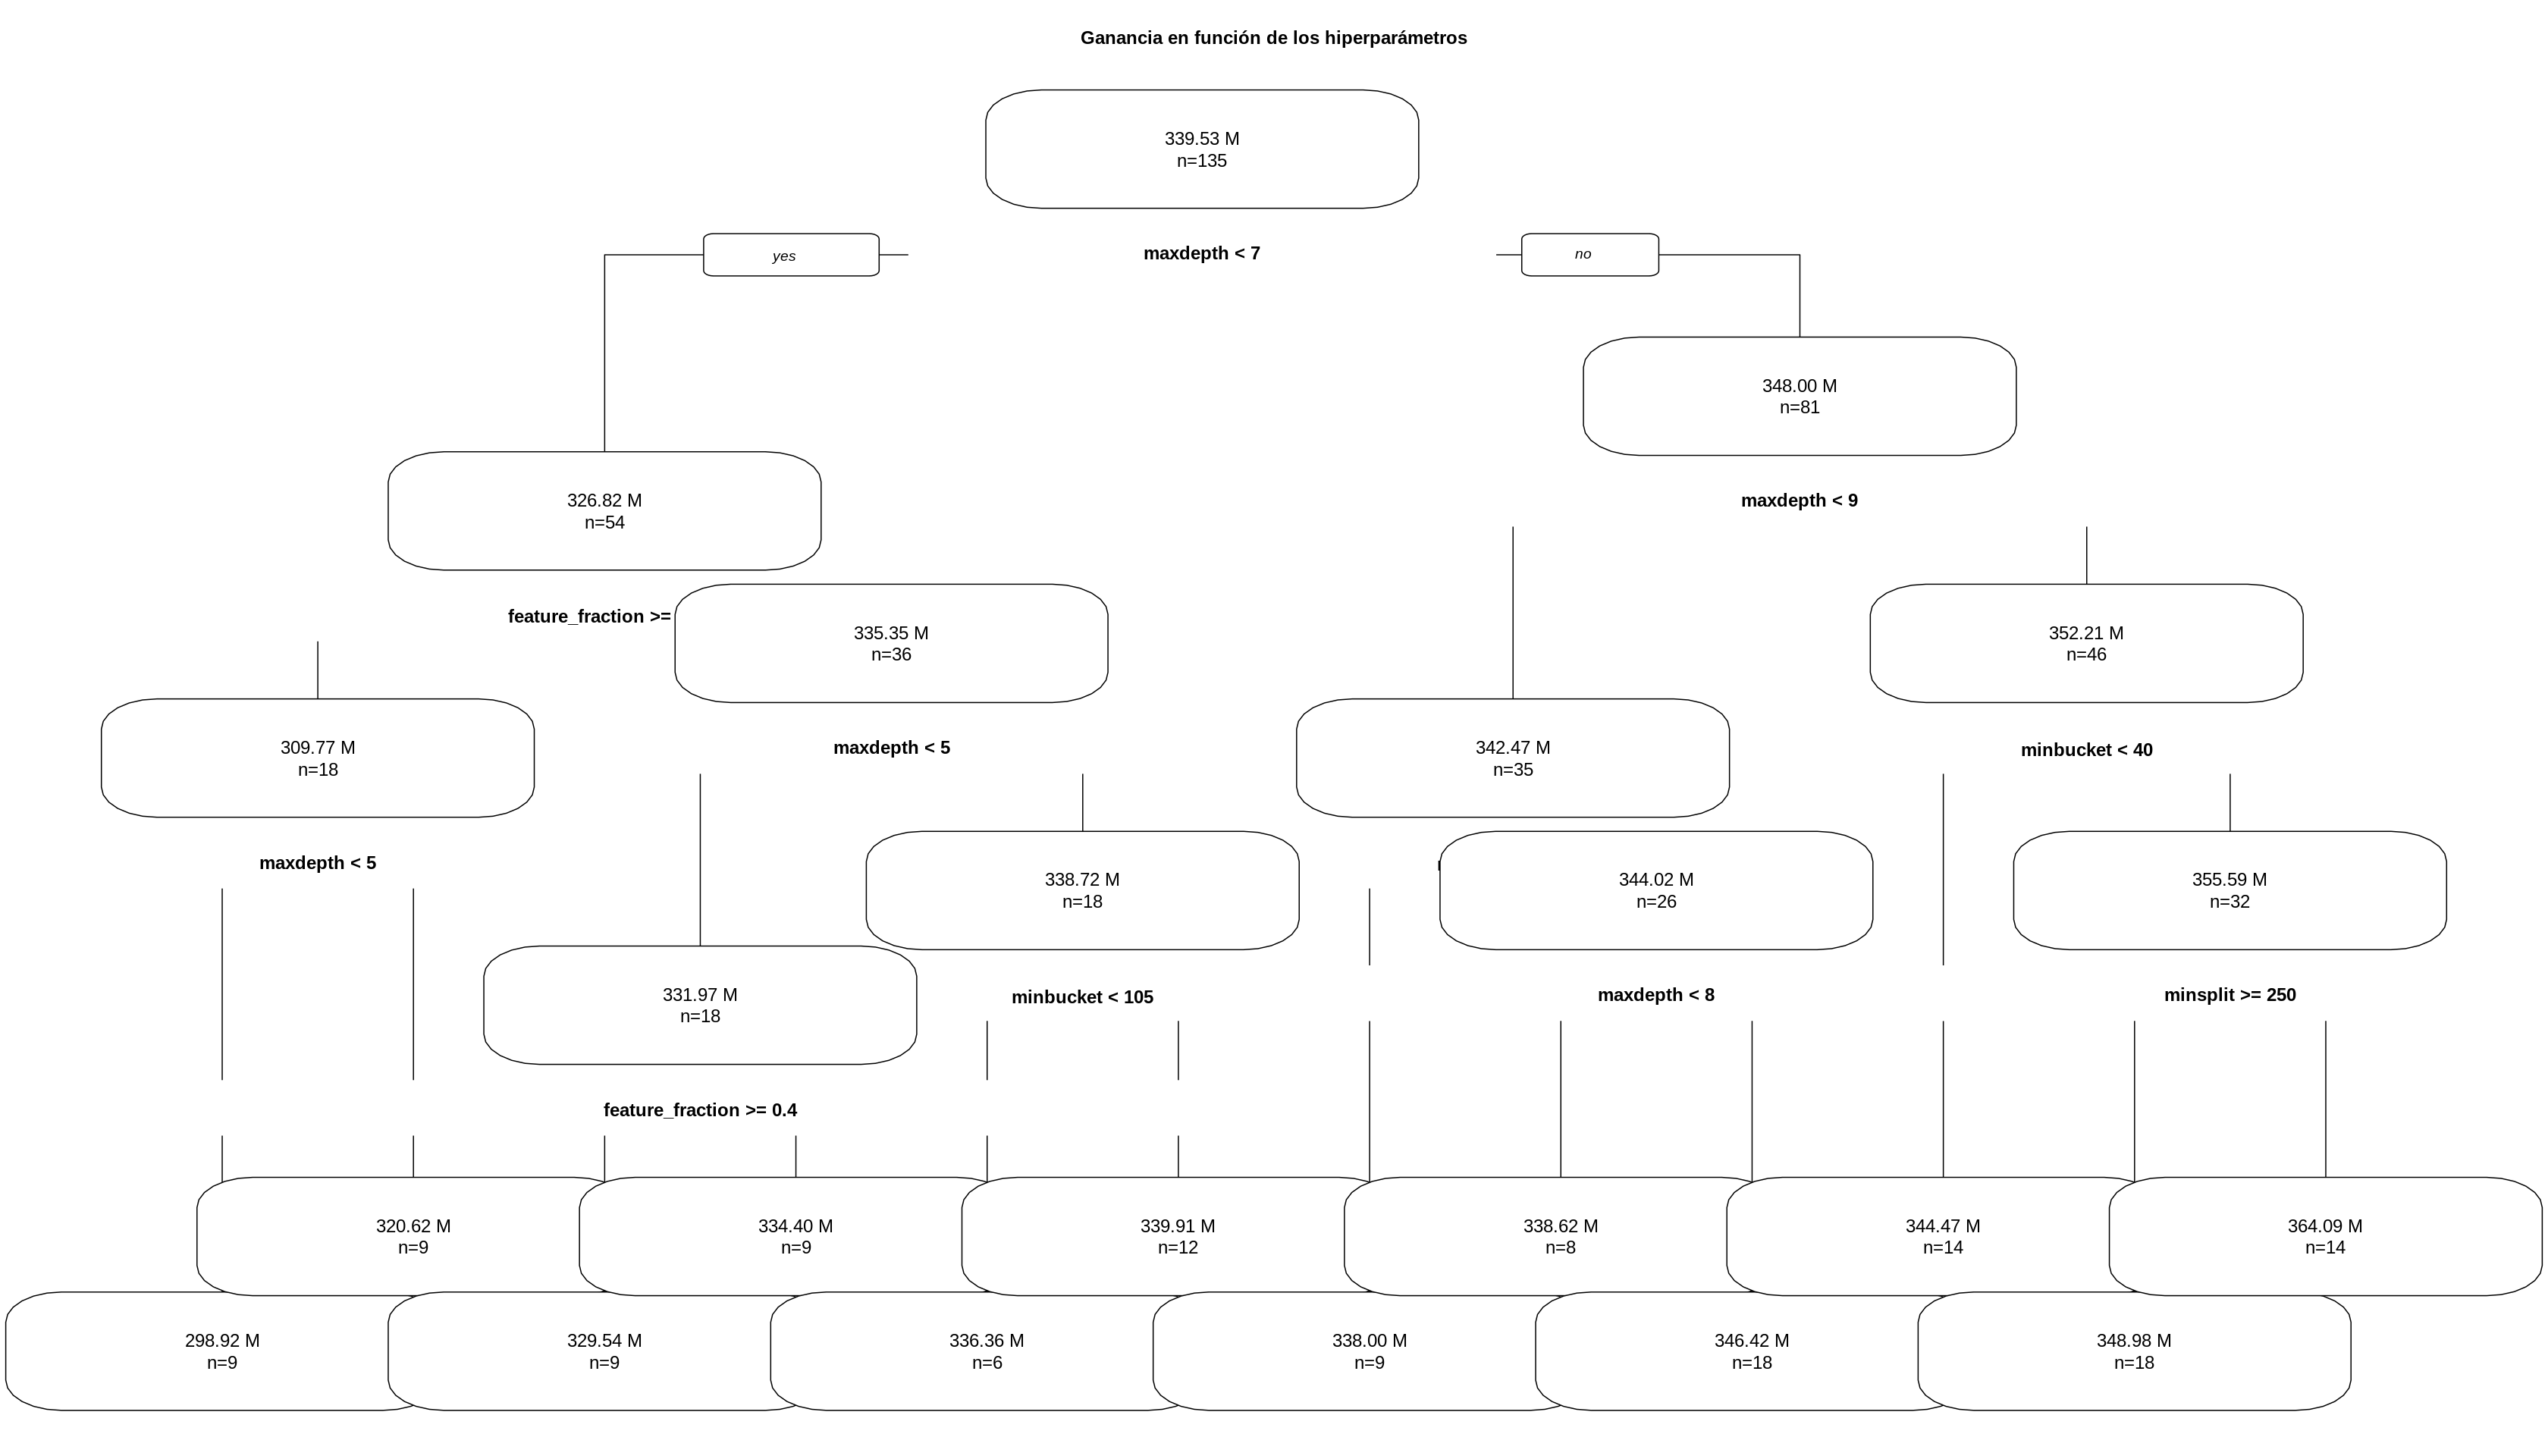

In [12]:
options(
  repr.plot.width = 28,
  repr.plot.height = 16
)

etiqueta_nodo <- function(x, labs, digits, varlen) {

  ganancia_millones <- x$frame$yval / 1000000

  paste0(
    format(
      round(ganancia_millones, 2),
      nsmall = 2,
      trim = TRUE
    ),
    " M",
    "\nn=",
    x$frame$n
  )
}

prp(
  modelo_ganancia,
  type = 2,
  extra = 0,
  branch = 1,

  varlen = 0,
  faclen = 0,

  node.fun = etiqueta_nodo,

  fallen.leaves = TRUE,

  # Compactación del árbol
  compress = TRUE,
  ycompress = TRUE,
  xcompact = TRUE,
  ycompact = TRUE,

  # Mantenemos la fuente legible
  cex = 1.20,
  tweak = 1.0,

  box.palette = 0,
  shadow.col = 0,

  main = "Ganancia en función de los hiperparámetros"
)

##Alternativa 2: Se ve muy bien y genera un gráfico en formato png

In [47]:
rpart_a_dot <- function(modelo) {

  frame <- modelo$frame
  nodos <- as.integer(row.names(frame))

  # ------------------------------------
  # Configuración gráfica
  # ------------------------------------

  lineas <- c(
    "digraph arbol {",
    "",
    "graph [",
    "  layout = dot,",
    "  rankdir = TB,",
    "  nodesep = 0.35,",
    "  ranksep = 0.55",
    "]",
    "",
    "node [",
    "  shape = box,",
    "  style = rounded,",
    "  fontname = Helvetica,",
    "  fontsize = 14,",
    "  margin = 0.12",
    "]",
    "",
    "edge [",
    "  fontname = Helvetica,",
    "  fontsize = 12",
    "]",
    ""
  )

  # ------------------------------------
  # Crear todos los nodos
  # ------------------------------------

  for (i in seq_along(nodos)) {

    nodo <- nodos[i]

    ganancia <- frame$yval[i] / 1e6
    cantidad <- frame$n[i]

    etiqueta <- sprintf(
      "%.2f M\\nn=%d",
      ganancia,
      cantidad
    )

    lineas <- c(
      lineas,
      sprintf(
        'n%d [label = "%s"];',
        nodo,
        etiqueta
      )
    )
  }

  lineas <- c(lineas, "")

  # ------------------------------------
  # Obtener caminos mediante rpart
  # ------------------------------------

  caminos <- path.rpart(
    modelo,
    nodes = nodos,
    print.it = FALSE
  )

  # ------------------------------------
  # Crear automáticamente las ramas
  # ------------------------------------

  for (i in seq_along(nodos)) {

    hijo <- nodos[i]

    # La raíz no tiene padre
    if (hijo == 1) next

    padre <- hijo %/% 2

    # El último elemento del camino es
    # la condición que conduce al hijo
    camino <- caminos[[i]]
    condicion <- tail(camino, 1)

    # Graphviz usa comillas dobles
    condicion <- gsub(
      '"',
      '\\"',
      condicion,
      fixed = TRUE
    )

    lineas <- c(
      lineas,
      sprintf(
        'n%d -> n%d [label = "%s"];',
        padre,
        hijo,
        condicion
      )
    )
  }

  lineas <- c(
    lineas,
    "}"
  )

  paste(
    lineas,
    collapse = "\n"
  )
}

In [50]:
grafico <- DiagrammeR::grViz(codigo_dot)

IRdisplay::display_html(
  DiagrammeRsvg::export_svg(grafico)
)

<?xml version="1.0" encoding="UTF-8" standalone="no"?>
<!DOCTYPE svg PUBLIC "-//W3C//DTD SVG 1.1//EN"
 "http://www.w3.org/Graphics/SVG/1.1/DTD/svg11.dtd">
<!-- Generated by graphviz version 2.40.1 (20161225.0304)
 -->
<!-- Title: arbol Pages: 1 -->
 
 
 arbol 
 
<!-- n1 -->
 
 n1 
 
 339.53 M 
 n=135 
 
<!-- n2 -->
 
 n2 
 
 326.82 M 
 n=54 
 
<!-- n1->n2 -->
 
 n1->n2 
 
 
 maxdepth< 6.5 
 
<!-- n3 -->
 
 n3 
 
 348.00 M 
 n=81 
 
<!-- n1->n3 -->
 
 n1->n3 
 
 
 maxdepth>=6.5 
 
<!-- n4 -->
 
 n4 
 
 309.77 M 
 n=18 
 
<!-- n2->n4 -->
 
 n2->n4 
 
 
 feature_fraction>=0.6 
 
<!-- n5 -->
 
 n5 
 
 335.35 M 
 n=36 
 
<!-- n2->n5 -->
 
 n2->n5 
 
 
 feature_fraction< 0.6 
 
<!-- n8 -->
 
 n8 
 
 298.92 M 
 n=9 
 
<!-- n4->n8 -->
 
 n4->n8 
 
 
 maxdepth< 5 
 
<!-- n9 -->
 
 n9 
 
 320.62 M 
 n=9 
 
<!-- n4->n9 -->
 
 n4->n9 
 
 
 maxdepth>=5 
 
<!-- n10 -->
 
 n10 
 
 331.97 M 
 n=18 
 
<!-- n5->n10 -->
 
 n5->n10 
 
 
 maxdepth< 5 
 
<!-- n11 -->
 
 n11 
 
 338.72 M 
 n=18 
 
<!-- n5->n11 -->
 
 n5->n11 
 
 
 maxdepth>=5 
 
<!-- n20 -->
 
 n20 
 
 329.54 M 
 n=9 
 
<!-- n10->n20 -->
 
 n10->n20 
 
 
 feature_fraction>=0.4 
 
<!-- n21 -->
 
 n21 
 
 334.40 M 
 n=9 
 
<!-- n10->n21 -->
 
 n10->n21 
 
 
 feature_fraction< 0.4 
 
<!-- n22 -->
 
 n22 
 
 336.36 M 
 n=6 
 
<!-- n11->n22 -->
 
 n11->n22 
 
 
 minbucket< 105 
 
<!-- n23 -->
 
 n23 
 
 339.91 M 
 n=12 
 
<!-- n11->n23 -->
 
 n11->n23 
 
 
 minbucket>=105 
 
<!-- n6 -->
 
 n6 
 
 342.47 M 
 n=35 
 
<!-- n3->n6 -->
 
 n3->n6 
 
 
 maxdepth< 9 
 
<!-- n7 -->
 
 n7 
 
 352.21 M 
 n=46 
 
<!-- n3->n7 -->
 
 n3->n7 
 
 
 maxdepth>=9 
 
<!-- n12 -->
 
 n12 
 
 338.00 M 
 n=9 
 
<!-- n6->n12 -->
 
 n6->n12 
 
 
 minbucket>=175 
 
<!-- n13 -->
 
 n13 
 
 344.02 M 
 n=26 
 
<!-- n6->n13 -->
 
 n6->n13 
 
 
 minbucket< 175 
 
<!-- n26 -->
 
 n26 
 
 338.62 M 
 n=8 
 
<!-- n13->n26 -->
 
 n13->n26 
 
 
 maxdepth< 7.5 
 
<!-- n27 -->
 
 n27 
 
 346.42 M 
 n=18 
 
<!-- n13->n27 -->
 
 n13->n27 
 
 
 maxdepth>=7.5 
 
<!-- n14 -->
 
 n14 
 
 344.47 M 
 n=14 
 
<!-- n7->n14 -->
 
 n7->n14 
 
 
 minbucket< 40 
 
<!-- n15 -->
 
 n15 
 
 355.59 M 
 n=32 
 
<!-- n7->n15 -->
 
 n7->n15 
 
 
 minbucket>=40 
 
<!-- n30 -->
 
 n30 
 
 348.98 M 
 n=18 
 
<!-- n15->n30 -->
 
 n15->n30 
 
 
 minsplit>=250 
 
<!-- n31 -->
 
 n31 
 
 364.09 M 
 n=14 
 
<!-- n15->n31 -->
 
 n15->n31 
 
 
 minsplit< 250

Código de salida: 0 
Existe PNG: TRUE 


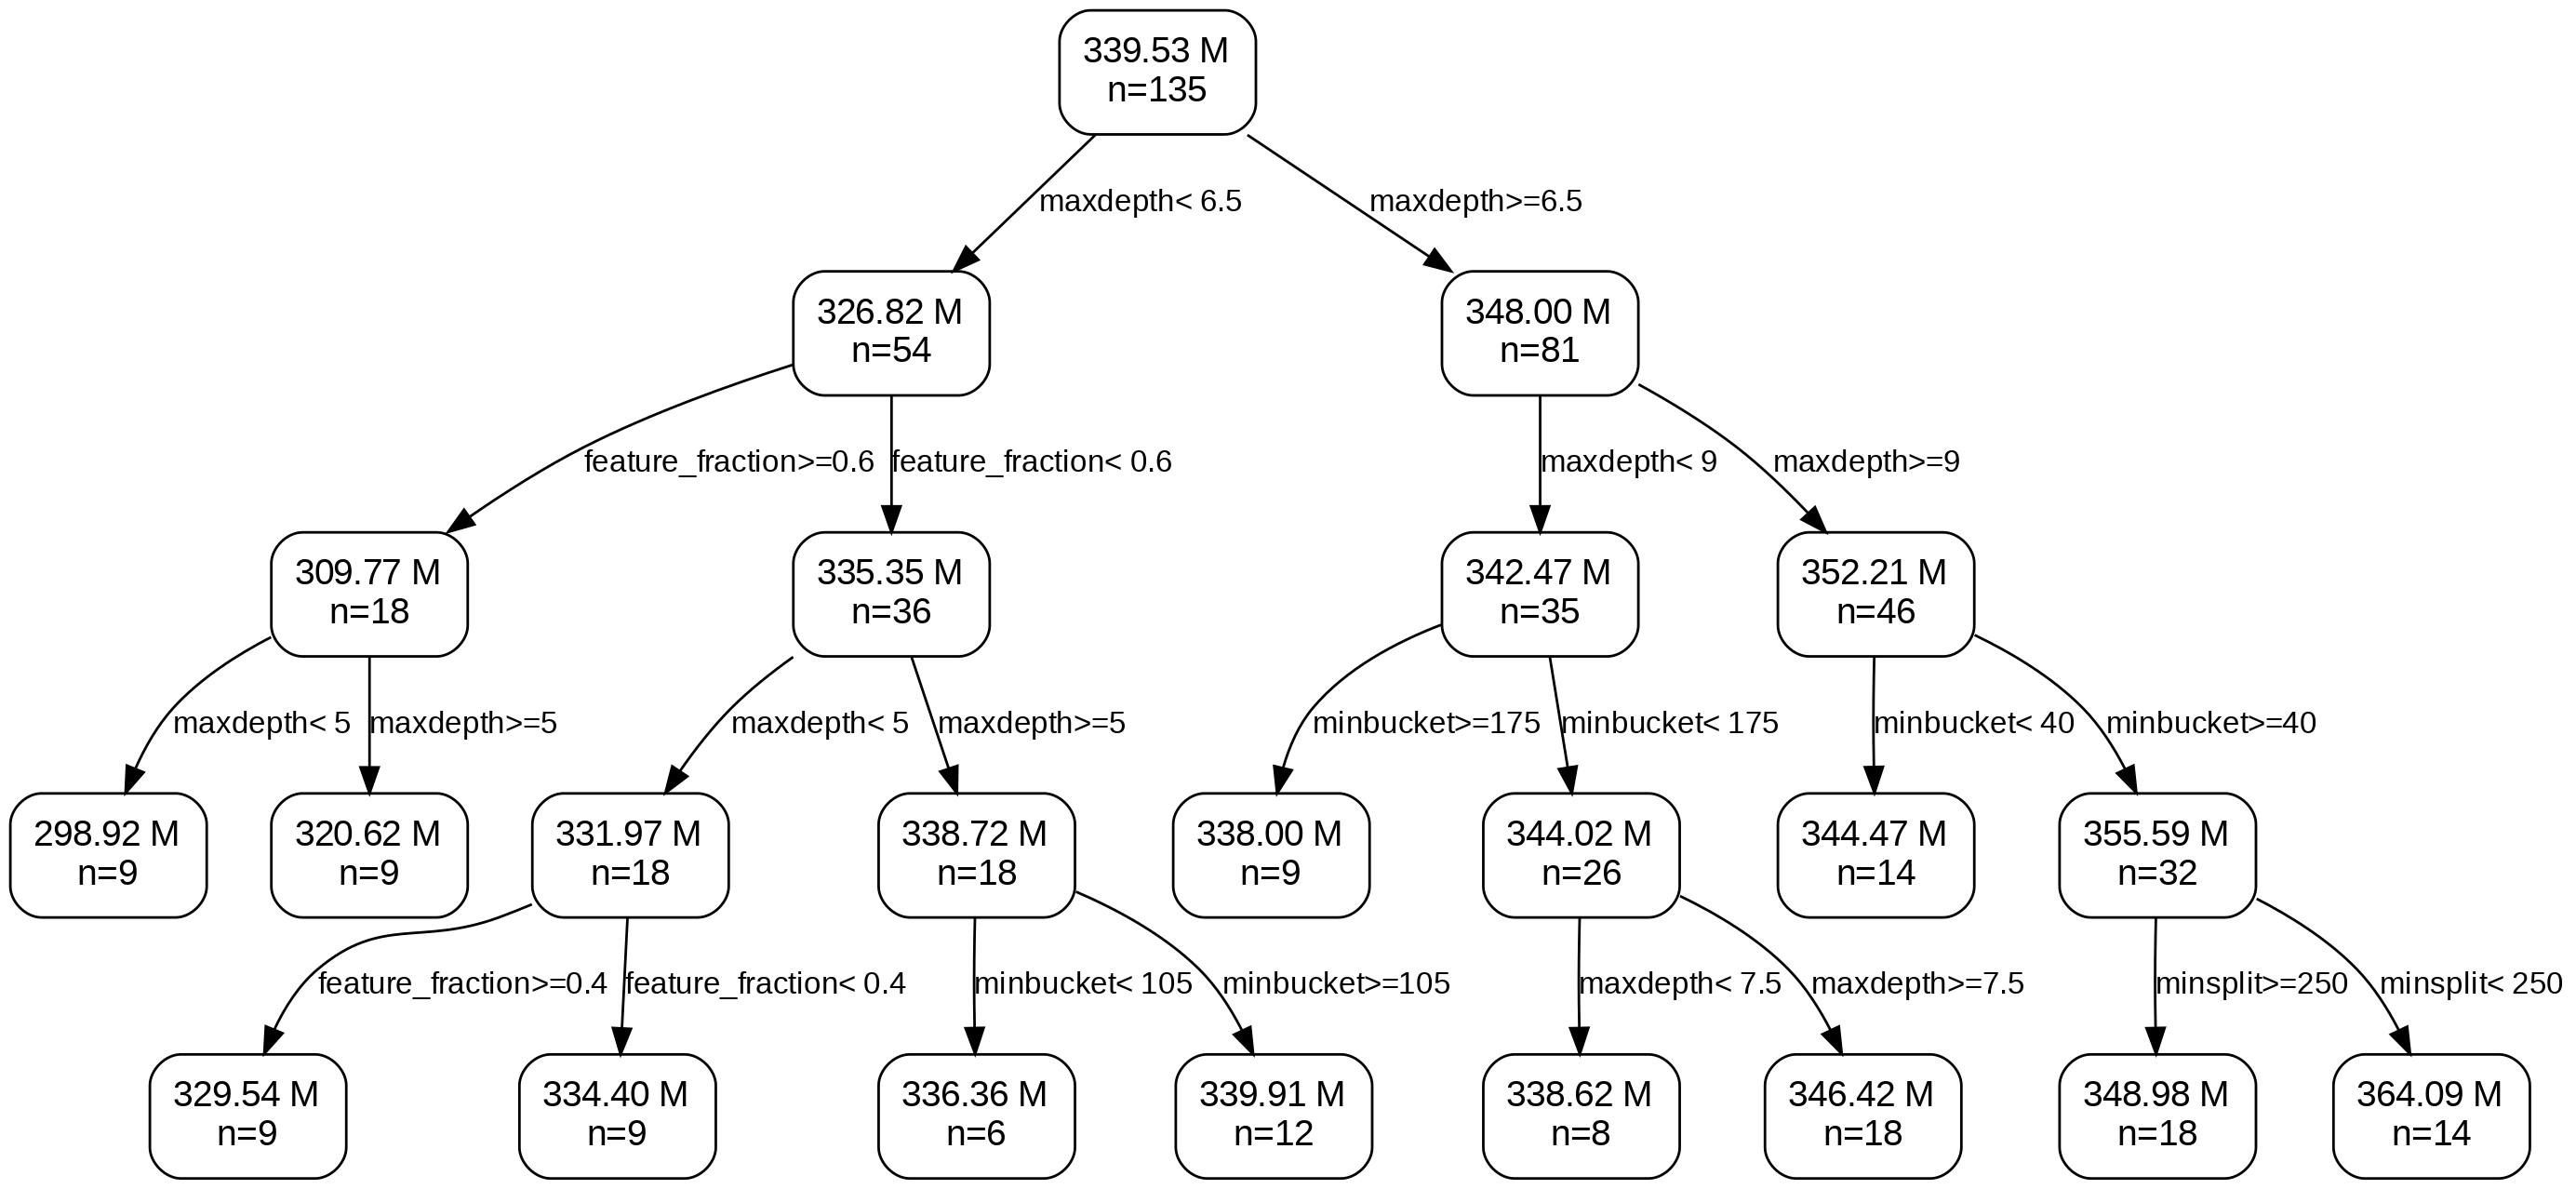

In [52]:
# Guardar el código DOT generado automáticamente
archivo_dot <- "/content/Arbol_Decision_Ganancias.dot"
writeLines(codigo_dot, archivo_dot)

# Generar PNG mediante Graphviz
archivo_png <- "/content/Arbol_Decision_Ganancias.png"

resultado <- system2(
  "dot",
  args = c(
    "-Tpng",
    "-Gdpi=200",
    archivo_dot,
    "-o",
    archivo_png
  )
)

cat("Código de salida:", resultado, "\n")
cat("Existe PNG:", file.exists(archivo_png), "\n")

IRdisplay::display_png(
  file = archivo_png
)

### Cómo leer el árbol

Cada división indica una condición sobre uno de los cuatro hiperparámetros.

Al avanzar desde la raíz hacia una hoja terminal se obtiene una combinación de condiciones.  
El valor mostrado en la hoja es la **ganancia promedio de los experimentos** que cumplen esas condiciones.

Por lo tanto, las hojas con valores más altos son las regiones del espacio de hiperparámetros que resultaron más favorables en los experimentos realizados.


## 7. Importancia de las variables

La importancia no indica por sí sola cuál es el mejor valor de cada hiperparámetro, pero ayuda a detectar cuáles fueron más influyentes en las divisiones realizadas por el árbol.


In [ ]:
importancia <- sort(modelo_ganancia$variable.importance, decreasing = TRUE)

data.table(
  variable = names(importancia),
  importancia = as.numeric(importancia)
)


## 8. Hojas terminales ordenadas por ganancia estimada

Este resumen permite identificar rápidamente qué regiones del árbol presentan las ganancias medias más altas.


In [ ]:
hojas <- which(modelo_ganancia$frame$var == "<leaf>")

resumen_hojas <- data.table(
  nodo = as.integer(row.names(modelo_ganancia$frame)[hojas]),
  cantidad_experimentos = modelo_ganancia$frame$n[hojas],
  ganancia_media = modelo_ganancia$frame$yval[hojas]
)

resumen_hojas[order(-ganancia_media)]


## 9. Experimento con mayor ganancia observada

Este resultado corresponde a una observación real del CSV, no a una predicción del árbol.


In [ ]:
dataset[which.max(ganancia)]


## Interpretación general

El árbol debe utilizarse como una herramienta **descriptiva y orientativa** para decidir hacia qué regiones de hiperparámetros conviene dirigir los próximos experimentos.

No significa que la combinación que aparece en la mejor hoja sea necesariamente el óptimo global: el árbol sólo puede aprender de los valores y combinaciones que ya fueron ensayados.
